Dataset Shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  

Training set size: 16512 samples
Testing set size: 4128 samples

=== Model Performance Comparison ===
                     RMSE  R2 Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Decision Tree      0.7242    0.5997

Best Performing Model: Decision Tree


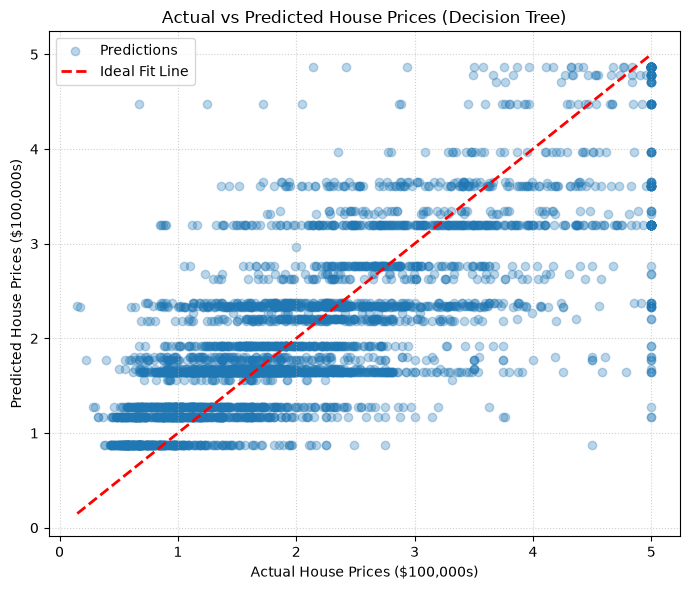

Model and scaler successfully saved to disk.


In [1]:
# %% Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Helper for RMSE across scikit-learn versions
def compute_rmse(y_true, y_pred):
    try:
        from sklearn.metrics import root_mean_squared_error
        return root_mean_squared_error(y_true, y_pred)
    except ImportError:
        return mean_squared_error(y_true, y_pred, squared=False)

# %% Step 2 & 3: Load Dataset and Separate Features/Target
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# %% Step 4 & 5: Train-Test Split & Feature Scaling
# Split first to prevent data leakage from the test set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# %% Step 6 & 7: Train Multiple Models and Evaluate
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    rmse = compute_rmse(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    }

results_df = pd.DataFrame(results).T
print("\n=== Model Performance Comparison ===")
print(results_df)

# Identify best model based on highest R2 Score / lowest RMSE
best_model_name = results_df["R2 Score"].idxmax()
best_model = models[best_model_name]
print(f"\nBest Performing Model: {best_model_name}")

# %% Step 8: Visual Performance Validation
y_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="#1f77b4", label="Predictions")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ideal Fit Line"
)
plt.xlabel("Actual House Prices ($100,000s)")
plt.ylabel("Predicted House Prices ($100,000s)")
plt.title(f"Actual vs Predicted House Prices ({best_model_name})")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# %% Optional Deliverable: Save Best Model & Scaler using joblib
joblib.dump(best_model, "best_housing_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Model and scaler successfully saved to disk.")